1.1 The operator (Hamiltonian)

In [11]:
from qiskit.quantum_info import SparsePauliOp
# Sparse N-qubit operator in a Pauli basis

hamiltonian = SparsePauliOp(
    [
        "IIII",
        "IIIZ",
        "IZII",
        "IIZI",
        "ZIII",
        "IZIZ",
        "IIZZ",
        "ZIIZ",
        "IZZI",
        "ZZII",
        "ZIZI",
        "YYYY",
        "XXYY",
        "YYXX",
        "XXXX",
    ],
    coeffs=[
        -0.09820182 + 0.0j,
        -0.1740751 + 0.0j,
        -0.1740751 + 0.0j,
        0.2242933 + 0.0j,
        0.2242933 + 0.0j,
        0.16891402 + 0.0j,
        0.1210099 + 0.0j,
        0.16631441 + 0.0j,
        0.16631441 + 0.0j,
        0.1210099 + 0.0j,
        0.17504456 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
    ],
)
# Hamiltonian for a simple Hydrogen molecule; Jordan-Wigner mapper
# Constructing a Hamiltonian for four qubits by tensor products of the Pauli matrices, number of Pauli
# matrices determined by the number of qubits

# ???? Grouping, commutation
# A Hamiltonian generally cannot be estimated all at once. We split up the basis into multiple
# groups to be estimated separately and finallly combine the results.

In [13]:
import numpy as np

A = np.array(hamiltonian) # Make the H into an array
eigenvalues, eigenvectors = np.linalg.eigh(A)
# Use classical eigensolver to find the eigenvalues and eigenvectors of a Hermitian matrix
print("The ground state energy is ", min(eigenvalues), "hartrees")

The ground state energy is  -1.1459778447627311 hartrees


3. Example Hamiltonian

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [24]:
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
) # Building the small hamiltonian from Pauli strings (N_{GCP} = 3)

A = np.array(hamiltonian) # making the Hamiltonian into an array
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("The ground state energy is: ", min(eigenvalues))

The ground state energy is:  -0.7029303944595311


This circuit has 4 parameters


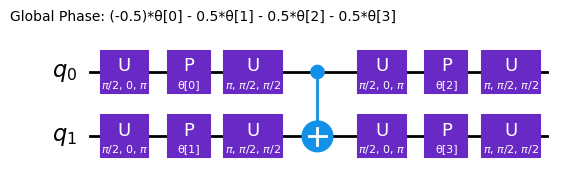

In [27]:
from qiskit.circuit.library import efficient_su2 # importing a prefabricated ansatz circuit and operator class

ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)
# input the number of qubits, gates to apply to each qubit, and entanglement structure. reps: number of repetition after entanglement. SU(2): Special Unitary 2-D matrices

num_parameters = ansatz.num_parameters
print("This circuit has", num_parameters, "parameters")
ansatz.decompose().draw("mpl", style="textbook") # drawing with matplotlib in textbook style

In [29]:
# from qiskit_ibm_runtime import QiskitRuntimeService, Session
# from qiskit_ibm_runtime import EstimatorV2 as Estimator

# service = QiskitRuntimeService()
# backend = service.least_busy(operational=1, simulator=1)

# print(backend)

# No account yet.

In [31]:
from qiskit.primitives import StatevectorEstimator as Estimator
# Local estimator
estimator = Estimator()

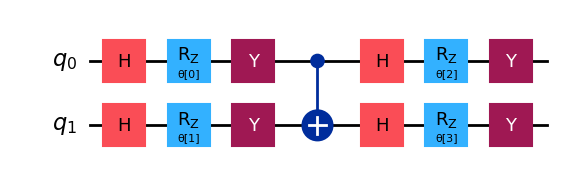

In [41]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# target = backend.target
pm = generate_preset_pass_manager(optimization_level=3)

ansatz_isa = pm.run(ansatz)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

# transpile the ansatz for our hardware and visualize

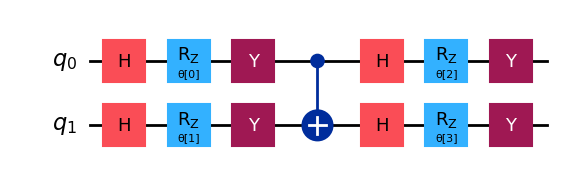

In [43]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Create a local simulator backend
backend = AerSimulator() 

# Now target = backend.target will work locally
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ansatz_isa = pm.run(ansatz)
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [39]:
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)
# mapping the Hamiltonian to match the qubits